# Creating a cluster toy model

## Instantiate the cluster


A few imports : 

In [10]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from astropy.io import fits
import jax.numpy as jnp
import numpy as np
import cmasher as cmr
import jax.random as random

from xifu_cluster_sim.xifu_config import XIFU_Config
from xifu_cluster_sim.cluster_cube import ClusterCube

In [2]:
cluster = ClusterCube()

## Create the cubes of cluster properties

The properties are the ones used for a bapec emission model : 
- norm
- temperature
- abundance
- redshift (cluster + gaussian random field)

In [3]:
cluster.create_density_cube()
cluster.create_norm_cube()
cluster.create_kT_cube()
cluster.create_Z_cube()

For the velocity, we need a random key.

In [5]:
rng_key = random.PRNGKey(42)
cluster.create_velocity_cube(rng_key)

Convert the velocity to redshift values, using the cluster redshift (set at 0.1 as default)

In [6]:
cluster.convert_velocity_to_redshift()

## Plot properties

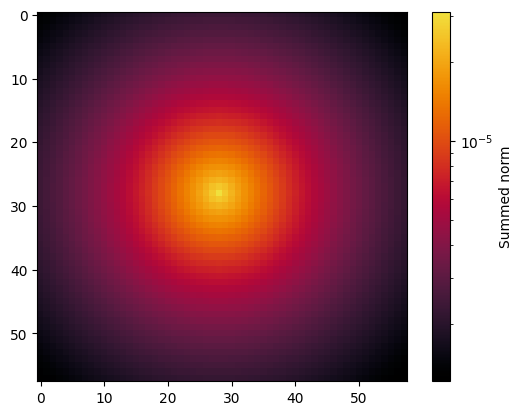

In [12]:
summed_norm = cluster.norm.sum(axis = -1)

plt.imshow(summed_norm, 
           cmap = cmr.ember, 
           norm = colors.LogNorm(vmin=summed_norm.min(), 
                                 vmax=summed_norm.max()))
plt.colorbar(label = 'Summed norm')

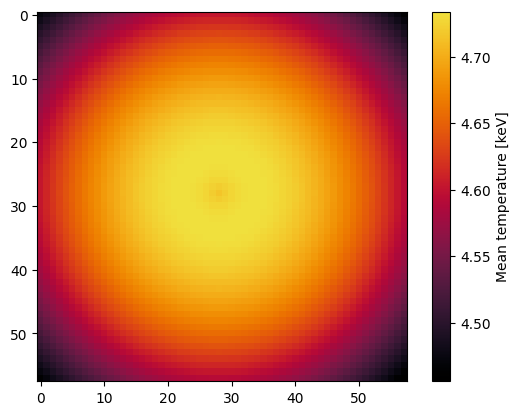

In [22]:
mean_kT = cluster.kT_cube.mean(axis = -1)

plt.imshow(mean_kT, 
           cmap = cmr.ember)
plt.colorbar(label = 'Mean temperature [keV]')

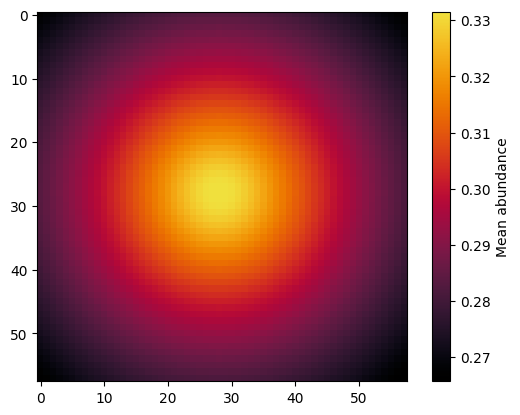

In [17]:
mean_Z = cluster.Z_cube.mean(axis = -1)

plt.imshow(mean_Z, 
           cmap = cmr.ember)
plt.colorbar(label = 'Mean abundance')

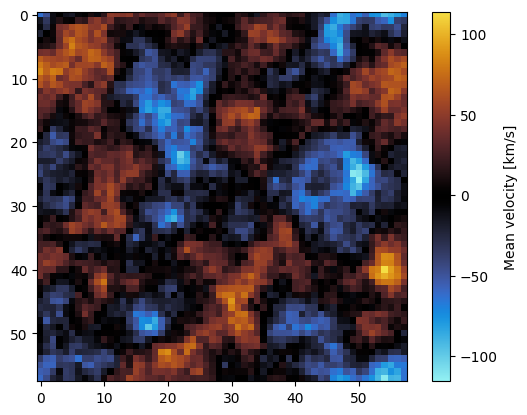

In [21]:
mean_v = cluster.v_cube.mean(axis = -1)

plt.imshow(mean_v, 
           cmap = cmr.iceburn)
plt.colorbar(label = 'Mean velocity [km/s]')